<td width="45%" valign="middle">
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="display:inline-block; vertical-align:middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="display:inline-block; vertical-align:middle;"
    >
  </div>
</td>

<td width="55%" align="right" valign="middle">
  <p style="margin: 0;"><b>Intelligence Data Science and Artificial Intelligence (IDEAI)</b></p>
  <p style="margin: 0;"><b>Grau en Estadística (UB - UPC)</b></p>
  <p style="margin: 0;">Anàlisis Multivariant de Dades (AMD)</p>
</td>

# **Árboles de decisión**

Este notebook está orientado a explicar árboles de decisión en clasificación:
- cómo dividen el espacio,
- cómo eligen variables y puntos de corte,
- interpretabilidad,
- control del sobreajuste,
- importancia de variables.

## Idea básica
Un árbol va haciendo preguntas del tipo:

- ¿`edad < 45`?
- ¿`saldo > 3000`?
- ¿`número de incidencias < 2`?

y termina en una hoja que produce una clase o una probabilidad.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.datasets import make_classification

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from plotnine import *

## 1. Criterios de partición

En clasificación, un árbol intenta reducir impureza en cada nodo.  
Los criterios más comunes son:

- **Gini**
- **Entropy**

### Intuición
Un nodo puro contiene casi todas las observaciones de una misma clase.

In [60]:
data = pd.read_csv("dataset_bancario_clean.csv")
df = data.copy()

In [61]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

In [62]:
X = df.drop(columns="default")
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

y = df["default"]

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

### Análisis explotatorio de datos


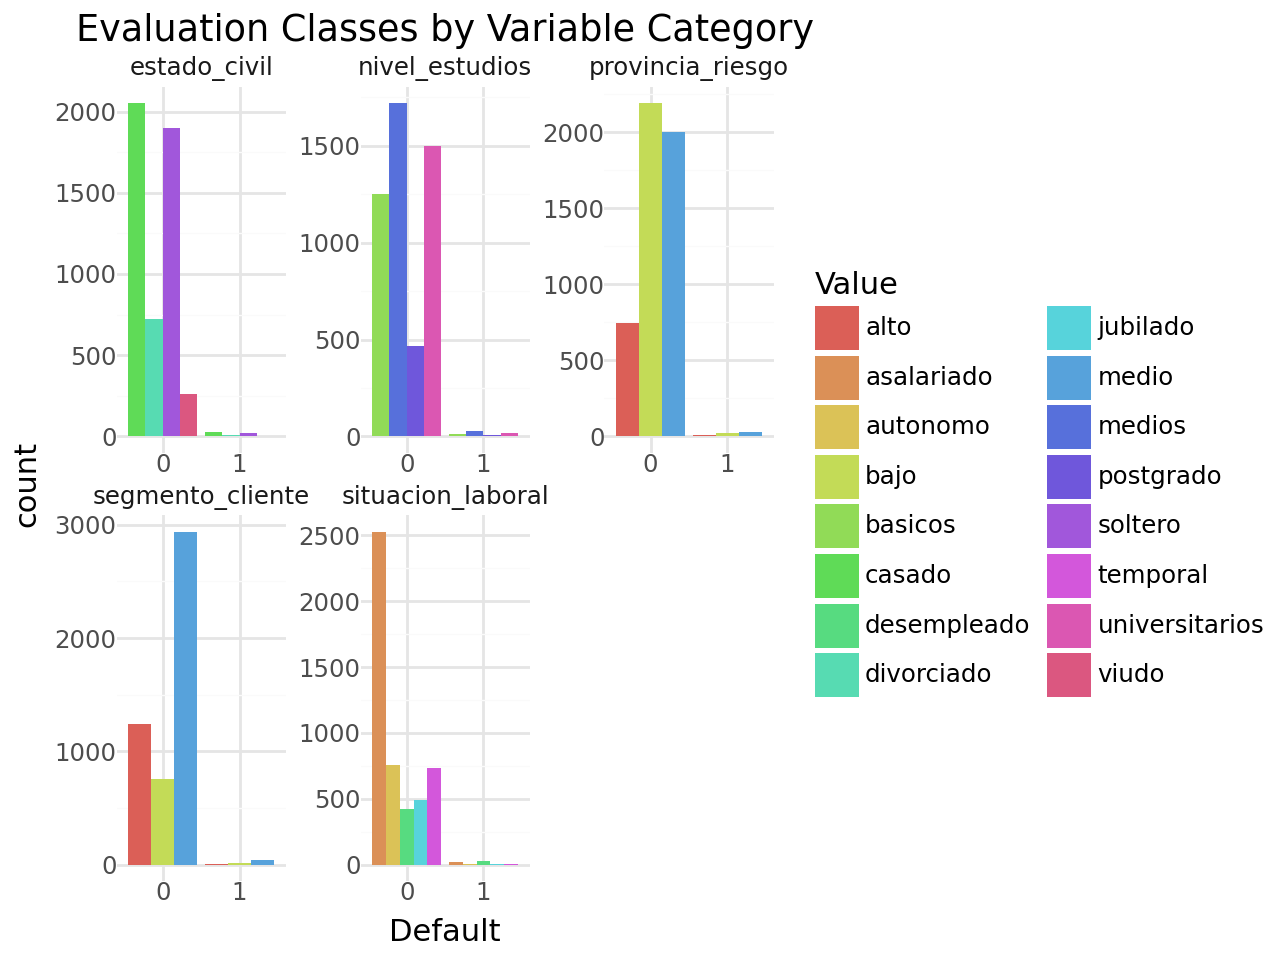

In [64]:
# Convertir a formato largo (clave para ggplot)
df_long = df.melt(id_vars="default", value_vars=cat_cols,
                  var_name="variable", value_name="value")

# Plot
(
    ggplot(df_long, aes(x="factor(default)", fill="factor(value)"))
    + geom_bar(position="dodge")
    + facet_wrap("~variable", scales="free", ncol=3)
    + labs(
        title="Evaluation Classes by Variable Category",
        x="Default",
        fill="Value"
    )
    + theme_minimal()
)

## 2. Entrenamiento de un árbol sencillo

In [65]:
arbol_generado = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_generado.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [66]:
pred = arbol_generado.predict(X_test)
proba = arbol_generado.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1       :", f1_score(y_test, pred))
print("ROC AUC  :", roc_auc_score(y_test, proba))

Accuracy : 0.9864
Precision: 0.0
Recall   : 0.0
F1       : 0.0
ROC AUC  : 0.6822672064777329


## 3. Visualización del árbol

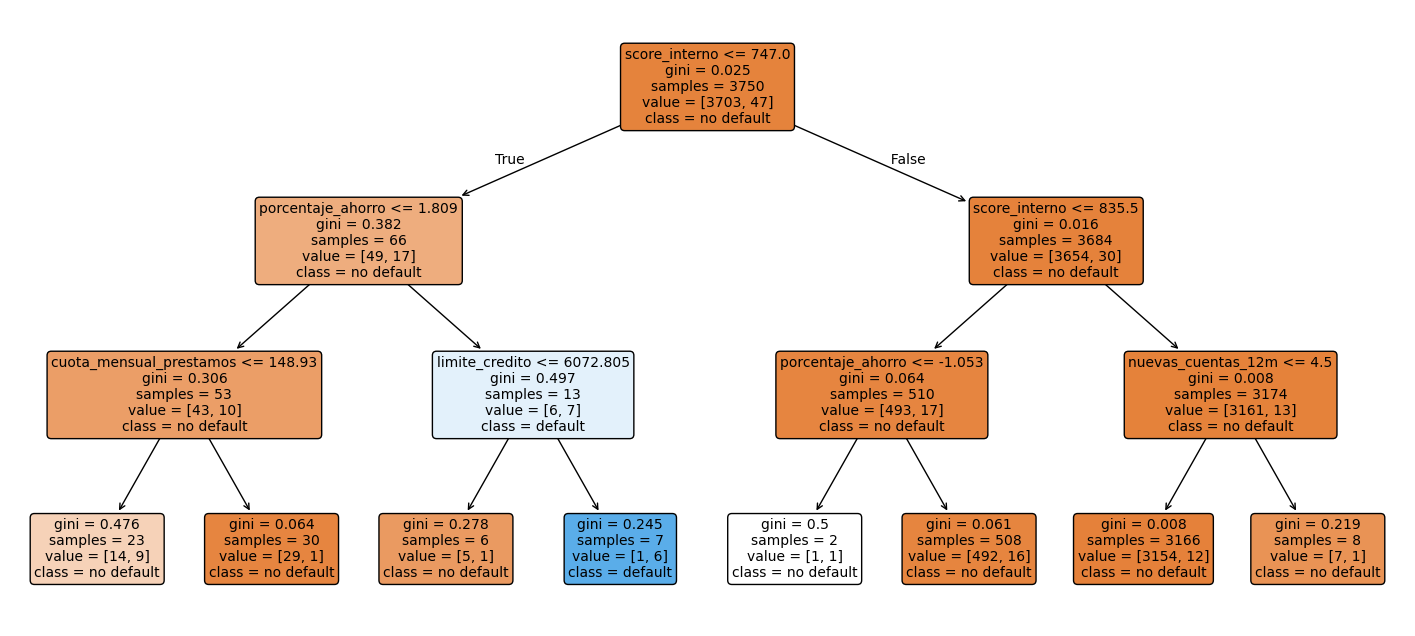

In [67]:
plt.figure(figsize=(18, 8))
plot_tree(
    arbol_generado,
    feature_names=X.columns,
    class_names=["no default", "default"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

También podemos extraer el árbol en texto, útil para documentación o revisión rápida.

In [68]:
print(export_text(arbol_generado, feature_names=X.columns))

|--- score_interno <= 747.00
|   |--- porcentaje_ahorro <= 1.81
|   |   |--- cuota_mensual_prestamos <= 148.93
|   |   |   |--- class: 0
|   |   |--- cuota_mensual_prestamos >  148.93
|   |   |   |--- class: 0
|   |--- porcentaje_ahorro >  1.81
|   |   |--- limite_credito <= 6072.80
|   |   |   |--- class: 0
|   |   |--- limite_credito >  6072.80
|   |   |   |--- class: 1
|--- score_interno >  747.00
|   |--- score_interno <= 835.50
|   |   |--- porcentaje_ahorro <= -1.05
|   |   |   |--- class: 0
|   |   |--- porcentaje_ahorro >  -1.05
|   |   |   |--- class: 0
|   |--- score_interno >  835.50
|   |   |--- nuevas_cuentas_12m <= 4.50
|   |   |   |--- class: 0
|   |   |--- nuevas_cuentas_12m >  4.50
|   |   |   |--- class: 0



## 4. Interpretación

Cada nodo muestra:
- la regla de corte,
- el número de muestras,
- la impureza,
- el reparto de clases.

Eso hace que el árbol sea muy interpretable frente a otros modelos más opacos.

## 5. Profundidad y sobreajuste

In [69]:
depths = range(1, 11)
rows = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    rows.append({
        "max_depth": d,
        "acc_train": accuracy_score(y_train, pred_train),
        "acc_test": accuracy_score(y_test, pred_test)
    })

depth_df = pd.DataFrame(rows)
depth_df

,max_depth,acc_train,acc_test
0,1,0.987467,0.9880
1,2,0.987733,0.9856
2,3,0.988800,0.9864
3,4,0.991200,0.9864
4,5,0.992800,0.9872
5,6,0.993867,0.9872
6,7,0.994667,0.9848
7,8,0.996267,0.9808
8,9,0.997067,0.9784
9,10,0.998400,0.9792


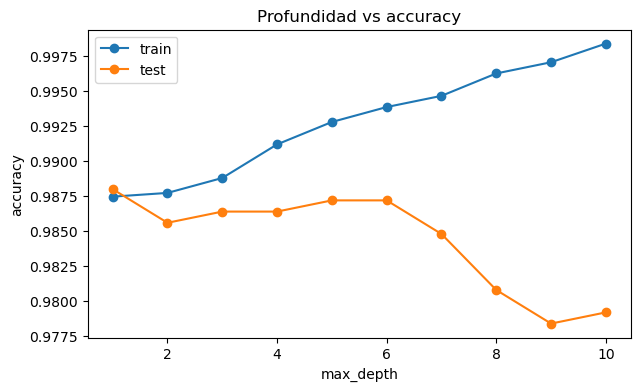

In [70]:
plt.figure(figsize=(7, 4))
plt.plot(depth_df["max_depth"], depth_df["acc_train"], marker="o", label="train")
plt.plot(depth_df["max_depth"], depth_df["acc_test"], marker="o", label="test")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Profundidad vs accuracy")
plt.legend()
plt.show()

Cuando accuracy en entrenamiento sigue subiendo y en test empeora, suele haber sobreajuste.

## 6. Otros hiperparámetros importantes

- `max_depth`: profundidad máxima
- `min_samples_split`: mínimo para dividir un nodo
- `min_samples_leaf`: mínimo por hoja
- `criterion`: gini o entropy
- `ccp_alpha`: poda por complejidad

Estos parámetros ayudan a controlar complejidad y estabilidad.

In [71]:
configs = [
    {"max_depth": 2, "min_samples_leaf": 1},
    {"max_depth": 4, "min_samples_leaf": 1},
    {"max_depth": 4, "min_samples_leaf": 10},
    {"max_depth": None, "min_samples_leaf": 1},
]

rows = []
for cfg in configs:
    model = DecisionTreeClassifier(random_state=42, **cfg)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({
        **cfg,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })
pd.DataFrame(rows)

,max_depth,min_samples_leaf,accuracy,f1
0,2.0,1,0.9856,0.000000
1,4.0,1,0.9864,0.190476
2,4.0,10,0.9864,0.190476
3,NaN,1,0.9776,0.125000


## 7. Optimización de parámetros

In [72]:
# Instancia del modelo
tree_inicial = DecisionTreeClassifier(random_state=42)

# parametros del decision tree
param_grid = {'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, 4, 5]}

# Realizar la búsqueda de hiperparámetros utilizando GridSearchCV
grid_search = GridSearchCV(tree_inicial, param_grid=param_grid, cv=10, return_train_score=True)
grid_search.fit(X_train, y_train)

# Imprimir los resultados
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print("Mejor puntuación de validación cruzada:")
print(grid_search.best_score_)


Mejores hiperparámetros encontrados:
{'criterion': 'gini', 'max_depth': 3}
Mejor puntuación de validación cruzada:
0.9874666666666666


In [73]:
# Modelo decision tree con parametros optimizados
best_tree = grid_search.best_estimator_

In [74]:
# Predecimos Y
y_train_pred_tree_car = best_tree.predict(X_train)
y_test_pred_tree_car = best_tree.predict(X_test)

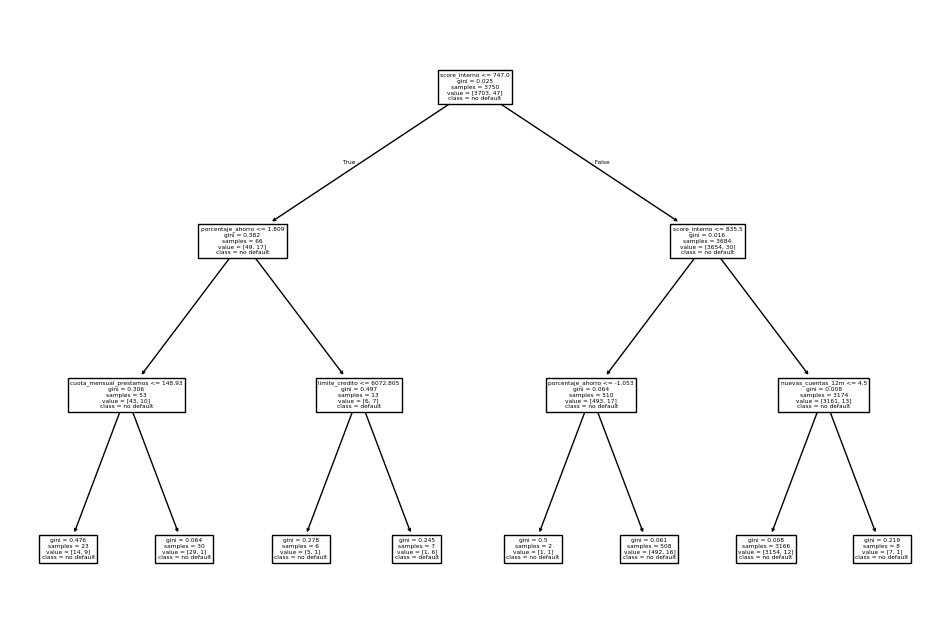

In [75]:
plt.figure(figsize = (12,8))
from sklearn import tree

tree.plot_tree(best_tree.fit(X_train, y_train), feature_names=X.columns,
    class_names=["no default", "default"]);
plt.show()

## 8. Importancia de variables

In [76]:
imp = pd.DataFrame({
    "variable": X.columns,
    "importance": best_tree.feature_importances_
}).sort_values("importance", ascending=False)

imp[imp["importance"] > 0]

,variable,importance
25,score_interno,0.466630
10,porcentaje_ahorro,0.181430
8,cuota_mensual_prestamos,0.176539
6,limite_credito,0.162995
17,nuevas_cuentas_12m,0.012406


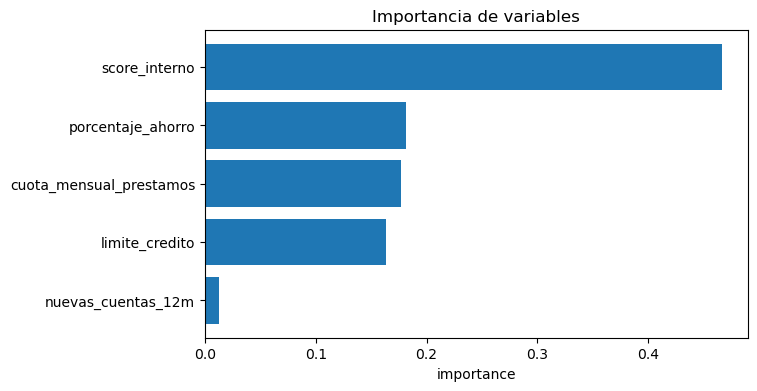

In [77]:
plt.figure(figsize=(7, 4))
plt.barh(imp.loc[imp["importance"] > 0, "variable"], imp.loc[imp["importance"] > 0, "importance"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables")
plt.xlabel("importance")
plt.show()

## 8. Pros y contras

### Pros
- Muy interpretables.
- Capturan relaciones no lineales.
- No requieren escalado.
- Soportan interacciones de forma natural.

### Contras
- Inestables ante pequeños cambios en datos.
- Tienden a sobreajustar si no se controlan.
- Su rendimiento puro a veces es inferior a ensamblados.

## 9. Ejercicios propuestos

### Ejercicio 1
Entrena un árbol con max_depth=2 y calcula accuracy y F1.

In [78]:
# Escribe aquí tu solución

### Ejercicio 2
Representa visualmente el árbol entrenado.

In [79]:
# Escribe aquí tu solución

### Ejercicio 3
Obtén el árbol en texto con export_text.

In [80]:
# Escribe aquí tu solución

### Ejercicio 4
Compara árboles con criterion='gini' y criterion='entropy'.

In [81]:
# Escribe aquí tu solución

### Ejercicio 5
Calcula accuracy train y test para profundidades de 1 a 8.

In [82]:
# Escribe aquí tu solución

### Ejercicio 6
Identifica la profundidad que parece equilibrar mejor sesgo-varianza.

In [83]:
# Escribe aquí tu solución

### Ejercicio 7
Entrena un árbol sin límite de profundidad y comenta si sobreajusta.

In [84]:
# Escribe aquí tu solución

### Ejercicio 8
Prueba min_samples_leaf=1, 5 y 20.

In [85]:
# Escribe aquí tu solución

### Ejercicio 9
Extrae la importancia de variables y represéntala.

In [86]:
# Escribe aquí tu solución

### Ejercicio 10
Escribe dos ventajas y dos limitaciones de los árboles en un entorno de auditoría.

In [87]:
# Escribe aquí tu solución

# Solucionario

In [88]:
# Solución 1
tree2 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree2.fit(X_train, y_train)
pred = tree2.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))

Accuracy: 0.9856
F1: 0.0


In [89]:
# Solución 2
plt.figure(figsize=(16, 6))
plot_tree(tree2, feature_names=features, class_names=["0", "1"], filled=True, rounded=True)
plt.show()

NameError: name 'features' is not defined

In [ ]:
# Solución 3
print(export_text(tree2, feature_names=features))

In [ ]:
# Solución 4
for crit in ["gini", "entropy"]:
    model = DecisionTreeClassifier(max_depth=3, criterion=crit, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(crit, accuracy_score(y_test, pred), f1_score(y_test, pred))

In [ ]:
# Solución 5
rows = []
for d in range(1, 9):
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    rows.append({
        "depth": d,
        "acc_train": accuracy_score(y_train, model.predict(X_train)),
        "acc_test": accuracy_score(y_test, model.predict(X_test))
    })
pd.DataFrame(rows)

In [ ]:
# Solución 6
print("La mejor profundidad suele ser donde el test deja de mejorar de manera consistente.")

In [ ]:
# Solución 7
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train, y_train)
print("Train:", accuracy_score(y_train, deep_tree.predict(X_train)))
print("Test :", accuracy_score(y_test, deep_tree.predict(X_test)))

In [ ]:
# Solución 8
for leaf in [1, 5, 20]:
    model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=leaf, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(leaf, accuracy_score(y_test, pred), f1_score(y_test, pred))

In [ ]:
# Solución 9
imp = pd.DataFrame({
    "variable": features,
    "importance": tree.feature_importances_
}).sort_values("importance", ascending=False)
display(imp)
plt.figure(figsize=(7,4))
plt.barh(imp["variable"], imp["importance"])
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Solución 10
print("Ventajas: interpretabilidad y facilidad para explicar reglas.")
print("Limitaciones: inestabilidad y tendencia al sobreajuste.")